In [5]:
from imagematerials.rest_of.sankey_function import create_node_dict, index_mapper, convert_index_to_node_id, prepare_Sankey_lists
from imagematerials.rest_of.fossil_fuels import *
                                                                                            
from imagematerials.read_mym import read_mym_df

from imagematerials.rest_of.const import path_scenario_data_fossil

In [6]:
# https://www.engineeringtoolbox.com/fossil-fuels-energy-content-d_1298.html




#%% read in and format relevant IMAGE data

# Total Primary Energy Supply (TPES) in PJ per region by energy carrier, [NRCT, PRIM + 4](t), [28,13](t), # unit: PJ
primary_energy_supply = read_mym_df(f'{path_scenario_data_fossil}/tpes_ext.out').set_index(["time", "DIM_1"])
# Primary to Secondary energy flows DIM_1:Primary, DIM_2:Secondary GJ/yr
prim_per_sec = read_mym_df(f'{path_scenario_data_fossil}/PrimPerSec.out').set_index(["time", "DIM_1", "DIM_2"])
# Final Energy in PJ/yr by region, sector, and energy carrier [NRCT, S, NECS9T](t), [28,8,10](t) # PJ
final_energy = read_mym_df(f'{path_scenario_data_fossil}/final_energy_rt.out').set_index(["time", "DIM_1", "DIM_2"])  

# Total Primary Energy Supply (TPES) in PJ/yr
# TODO: region 27 has some values? Why? it is not exactly the sum of sth...
primary_energy_supply = primary_energy_supply.T  # transpose to make DIM_2 the index (DIM_1 is regions, make this columns)
primary_energy_supply = primary_energy_supply.stack('time')  # add years as index
primary_energy_supply = primary_energy_supply.swaplevel()  # make years the first index
primary_energy_supply = primary_energy_supply.sort_index()  # sort dataframe based on the index
primary_energy_supply.index.names = ['time','DIM_2']

# Primary to Secondary energy flows in GJ/yr
prim_per_sec = prim_per_sec/giga_to_peta # GJ to PJ
prim_per_sec = prim_per_sec.rename(columns={27: 28}) # rename 27 to 28 to fit other dfs
prim_per_sec[27] = np.nan # create empty dummy 27 region
prim_per_sec = prim_per_sec[sorted(prim_per_sec.columns)] # sort so that 27 is before 28

# Final Energy in PJ/yr 
#TODO: region 27 is empty
final_energy = final_energy.T # transpose to make DIM_1 the index
final_energy = final_energy.stack(['time', 'DIM_2'])  # add years as and DIM_2 index
final_energy.index.names = ['DIM_3', 'time', 'DIM_2']
final_energy = final_energy.swaplevel(0, 1)  # make years the first index

#%% Fossil energy only

fossils_primary = primary_energy_supply.query(parse_dim('primary', '2', 'coal' ,'oil', 
                                                        'natural gas'))
fossils_prim_per_sec = prim_per_sec.query(parse_dim('primsec_reversed', '1', 'coal', 
                                                    'conventional oil', 'unconventional oil', 
                                                    'natural gasses'))
fossils_final = final_energy.query(parse_dim('seconden_reversed', '3', 'coal',
                                             'heavy oil', 'light oil', 'natural gas'))

C:\Users\Arp00003\AppData\Local\Temp\ipykernel_24928\4263414025.py:18: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.

C:\Users\Arp00003\AppData\Local\Temp\ipykernel_24928\4263414025.py:32: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.



In [7]:
fossils_primary_converted = converte_primary_energy_to_mass(fossils_primary)
fossils_primsecond_converted = convert_primary_to_secondary_to_mass(fossils_prim_per_sec)
fossils_final_converteted = convert_secondary_to_final_mass(fossils_final)





C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\fossil_fuels.py:105: PerformanceWarning:

indexing past lexsort depth may impact performance.

C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\fossil_fuels.py:111: PerformanceWarning:

indexing past lexsort depth may impact performance.

C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\fossil_fuels.py:111: PerformanceWarning:

indexing past lexsort depth may impact performance.



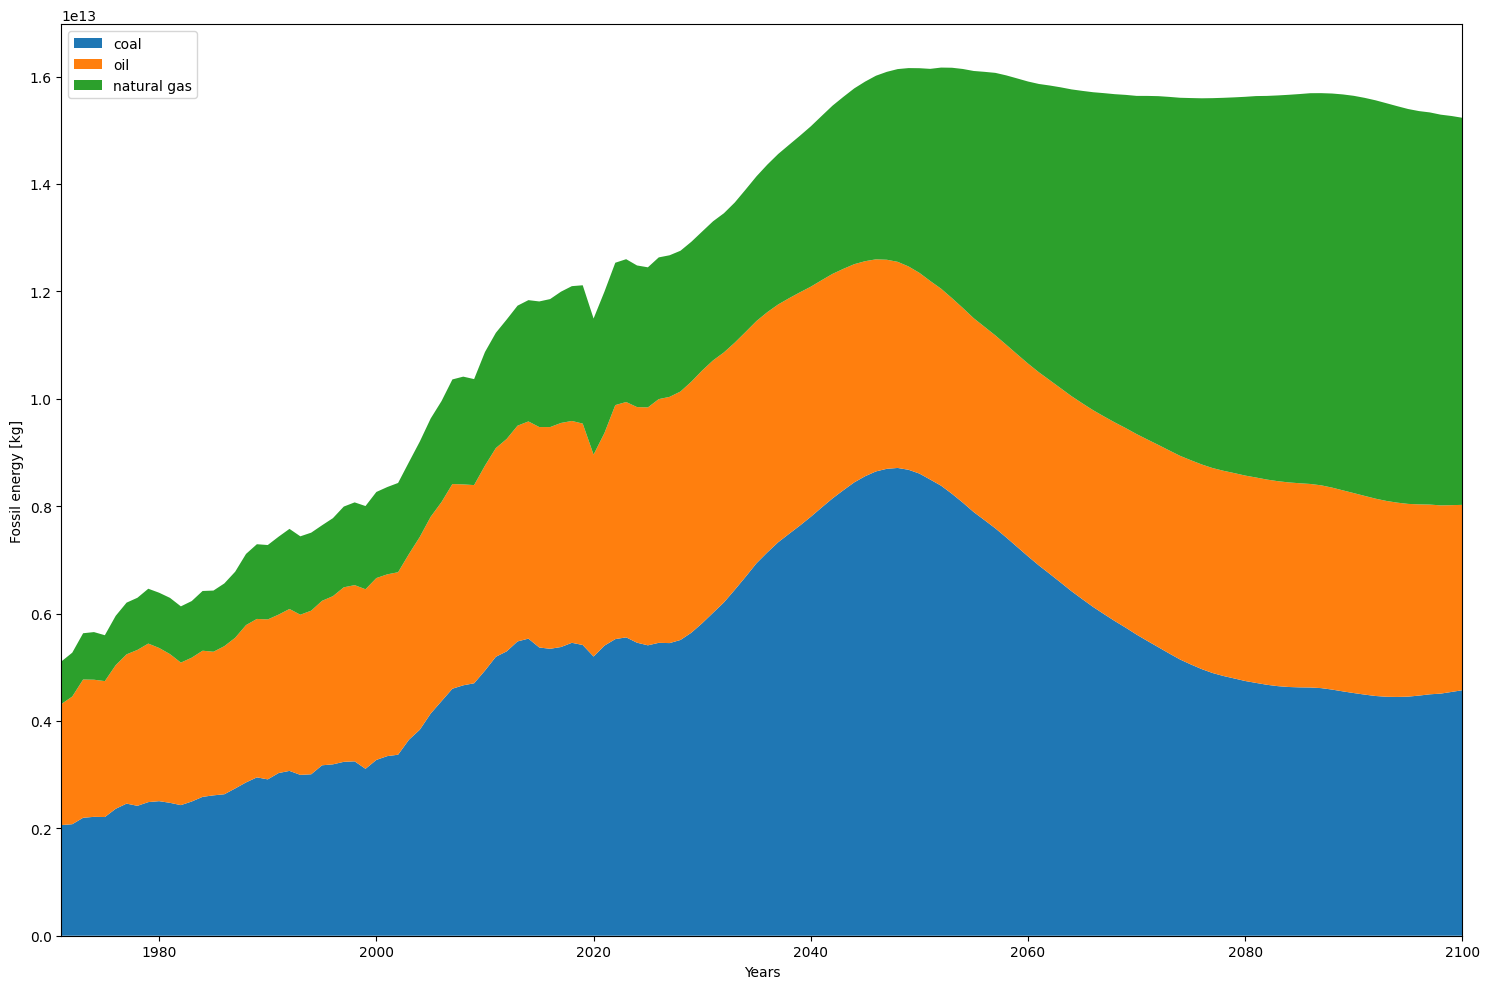

In [8]:
fossils_stacked_line = plot_stacked_fossils(28, fossils_primary_converted, 'kg')

# IN KG
fossils_sankey = plot_fossils_sankey(2050, 28, fossils_primsecond_converted, fossils_final_converteted, 
                                        DIM1_primsec_dict, DIM2_primsec_dict, DIM3_seconden_dict, DIM2_sectors_dict, 'kg')
# IN MJ
fossils_sankey = plot_fossils_sankey(2050, 28, fossils_prim_per_sec, fossils_final, 
                                        DIM1_primsec_dict, DIM2_primsec_dict, DIM3_seconden_dict, DIM2_sectors_dict, 'MJ')